# Railway Inventory Planning Platform — Notebook 7 (Rebuilt, STEP30)
**Division MAS · STEP1–28 + Hardening · all figures computed live from current outputs.**

Audience: Stores Officers · Sr.DMM · COS · DRM · PCSTE · Railway Board · Auditors · Engineers · Researchers. Understandable without reading source code.

*MASTER — full 16-section platform notebook.*

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, pandas as pd
from pathlib import Path
import sys; sys.path.insert(0, str(Path.cwd().parent))
from railway import railway_config as cfg
from railway.governance import division_summary as ds
sns.set_theme(style="whitegrid", palette="deep"); plt.rcParams["figure.dpi"]=110
H = cfg.OUTPUT_DIR / "MAS" / "history"
def rd(n): return pd.read_csv(H/n, dtype={"PL_Code":str}, keep_default_na=False)
def num(s): return pd.to_numeric(s, errors="coerce").fillna(0)
dc=rd("demand_classification.csv"); fc=rd("forecast_results.csv"); lt=rd("lead_time_master.csv")
ssr=rd("safety_stock_results.csv"); rop=rd("rop_results.csv"); srrs=rd("srss_results.csv")
pp=pd.read_csv(H/"procurement_portfolio.csv"); mdh=rd("monthly_demand_history.csv")
score=pd.read_csv(H/"platform_scorecard.csv"); tpj=pd.read_csv(H/"tpj_onboarding_readiness.csv")
for c in ["Current_Stock","ROP","Positive_Gap","SRRS","Average_Rate_Rs","Reorder_Gap_Value_Rs"]:
    if c in srrs: srrs[c]=num(srrs[c])
for c in ["Safety_Stock","Lead_Time_Days","Reorder_Gap","Demand_During_LT","Forecast_Annual"]:
    if c in rop: rop[c]=num(rop[c])
ssr["Safety_Stock"]=num(ssr["Safety_Stock"])
META=ds.metadata(generation_date="2026-06-08"); KPI=ds.compute_kpis()
print("Loaded current outputs:", {"demand":len(dc),"forecast":len(fc),"lead_time":len(lt),
      "safety_stock":len(ssr),"rop":len(rop),"srrs":len(srrs)})

Loaded current outputs: {'demand': 1083, 'forecast': 961, 'lead_time': 702, 'safety_stock': 626, 'rop': 626, 'srrs': 626}


## 1. Railway Inventory Planning Platform — Overview
**Southern Railway spare-parts inventory planning**, division **MAS**. This notebook is the
canonical platform reference — technical reference, executive dashboard, business case,
platform documentation, and deployment-readiness review — covering the full lifecycle:
**Walmart lineage → Railway Transformation (STEP1–19) → MAS Planning (STEP20–28) → Hardening → TPJ Readiness**.
All figures are computed live from current generated outputs.

In [2]:
print("PLATFORM METADATA / PROVENANCE")
for k,v in META.items(): print(f"  {k:<18}: {v}")

PLATFORM METADATA / PROVENANCE
  Platform Version  : Railway Inventory Planning Platform v1.0 (STEP1-28 + Hardening A/B)
  Division          : MAS
  Data Date         : 08-06-2026
  Git Commit        : 42264b5
  Generation Date   : 2026-06-08
  Pipeline Version  : STEP1-19 core + STEP20-28 MAS extension
  Readiness Score   : 43.9 -> 76.7 (target)


## 2. Platform Architecture
Layered platform: **ingestion** (consolidated I/O) → **governance/config** (division registry) →
**core analytics (STEP1–19)** → **MAS extension (STEP20–28)**, protected by a reproducible
regression + formula test suite (Hardening A/B).

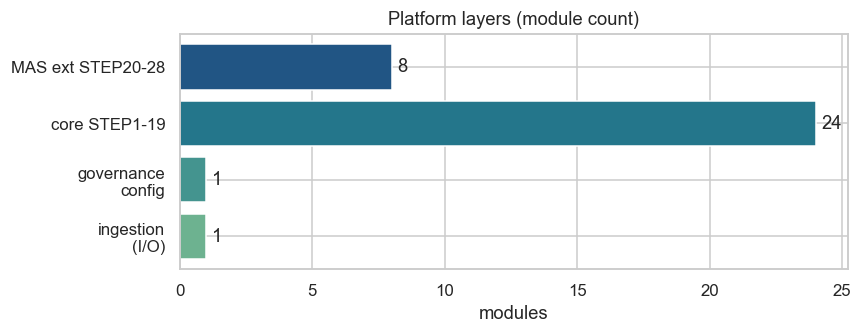

Dependency rule: ingestion -> demand -> forecasting -> inventory -> prioritization -> reporting


In [3]:
layers = {"ingestion\n(I/O)":1,"governance\nconfig":1,"core STEP1-19":24,"MAS ext STEP20-28":8}
fig,ax=plt.subplots(figsize=(8,3.2))
ax.barh(list(layers.keys()), list(layers.values()), color=sns.color_palette("crest",4))
ax.set_title("Platform layers (module count)"); ax.set_xlabel("modules")
for i,v in enumerate(layers.values()): ax.text(v+0.2,i,str(v),va="center")
plt.tight_layout(); plt.show()
print("Dependency rule: ingestion -> demand -> forecasting -> inventory -> prioritization -> reporting")

## 3. Data Foundation
**What data powers the platform?** DMTR issue/procurement registers, SUMMARY OF STOCK HELD
(depot 027534), and the strategic/operational workbooks. Coverage across the planning funnel.

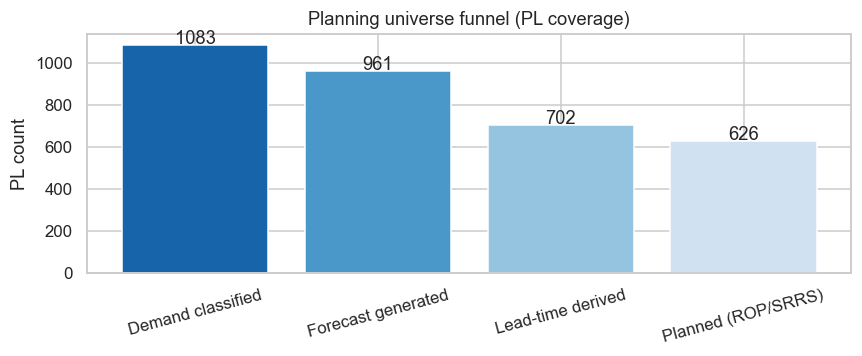

In [4]:
funnel={"Demand classified":len(dc),"Forecast generated":len(fc),"Lead-time derived":len(lt),
        "Planned (ROP/SRRS)":len(rop)}
fig,ax=plt.subplots(figsize=(8,3.4))
ax.bar(funnel.keys(), funnel.values(), color=sns.color_palette("Blues_r",4))
ax.set_title("Planning universe funnel (PL coverage)"); ax.set_ylabel("PL count")
for i,v in enumerate(funnel.values()): ax.text(i,v+8,str(v),ha="center")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 4. Demand Reconstruction (STEP21A)
**How does MAS consume inventory?** 54 months reconstructed from DMTR issues. Railway spares are
overwhelmingly intermittent.

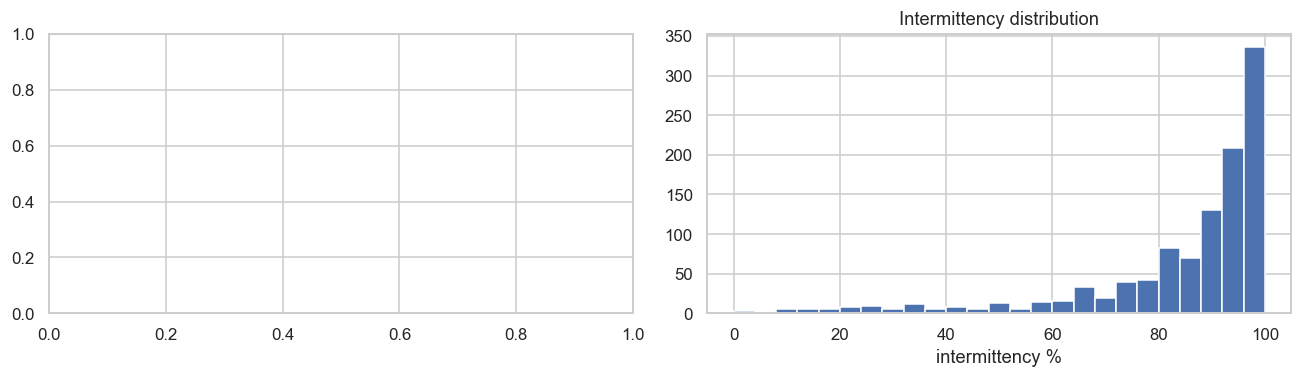

In [5]:
month_cols=[c for c in mdh.columns if c[:1].isdigit() or "20" in c]
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
if month_cols:
    series=num(mdh[month_cols].apply(pd.to_numeric,errors="coerce").sum(axis=0))
    axes[0].plot(range(len(series)), series.values, marker="o", ms=3)
    axes[0].set_title("Aggregate monthly demand (all PLs)"); axes[0].set_xlabel("month index")
inter=num(dc["Intermittency_Pct"]) if "Intermittency_Pct" in dc else num(dc.get("Months_Without_Demand"))
axes[1].hist(inter, bins=25, color="#4c72b0"); axes[1].set_title("Intermittency distribution")
axes[1].set_xlabel("intermittency %")
plt.tight_layout(); plt.show()

## 5. Forecasting (STEP22–23)
**How forecastable is the universe?** Syntetos–Boylan classification (ADI 1.32 / CV² 0.49) routes
each PL to SBA / TSB / Croston / SES-Holt. Coverage **88.7%**.

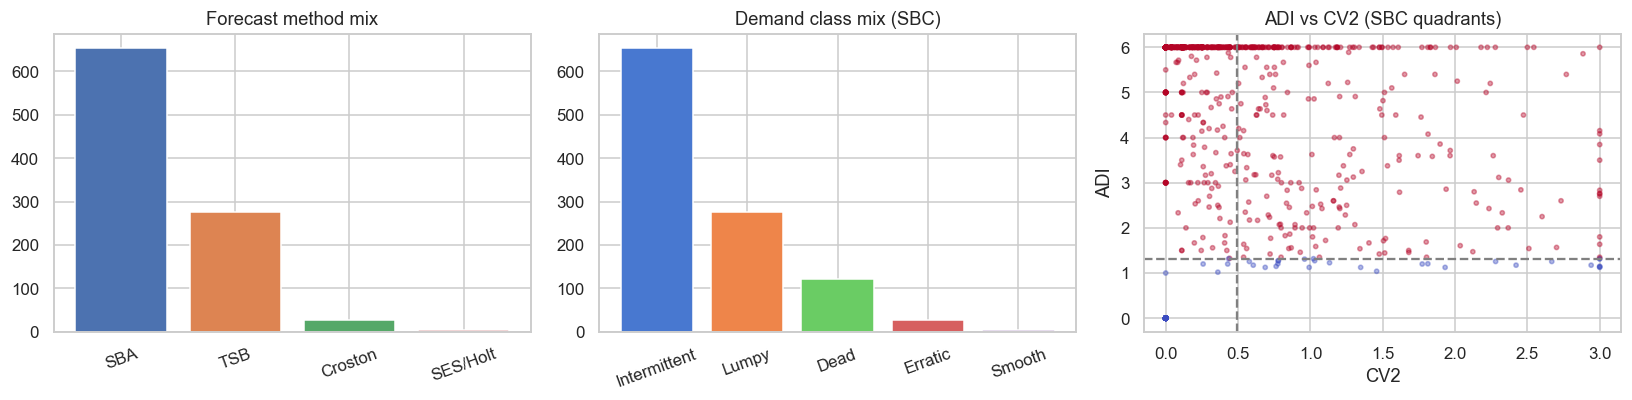

In [6]:
fig,axes=plt.subplots(1,3,figsize=(15,3.8))
mm=fc["Forecast_Method"].value_counts()
axes[0].bar(mm.index, mm.values, color=sns.color_palette("deep",len(mm)))
axes[0].set_title("Forecast method mix"); axes[0].tick_params(axis="x",rotation=20)
cm=dc["Demand_Class"].value_counts()
axes[1].bar(cm.index, cm.values, color=sns.color_palette("muted",len(cm)))
axes[1].set_title("Demand class mix (SBC)"); axes[1].tick_params(axis="x",rotation=20)
adi=num(dc["ADI"]); cv2=num(dc["CV2"])
sc=axes[2].scatter(cv2.clip(0,3), adi.clip(0,6), s=8, alpha=0.4, c=(adi>=1.32).astype(int), cmap="coolwarm")
axes[2].axhline(1.32,ls="--",c="grey"); axes[2].axvline(0.49,ls="--",c="grey")
axes[2].set_title("ADI vs CV2 (SBC quadrants)"); axes[2].set_xlabel("CV2"); axes[2].set_ylabel("ADI")
plt.tight_layout(); plt.show()

## 6. Lead-Time Analytics (STEP23.6B)
**What drives replenishment delay?** Real lead times derived from DMTR procurement chronology
(PO→Receipt, Reqn→Receipt). Coverage **97.8%**.

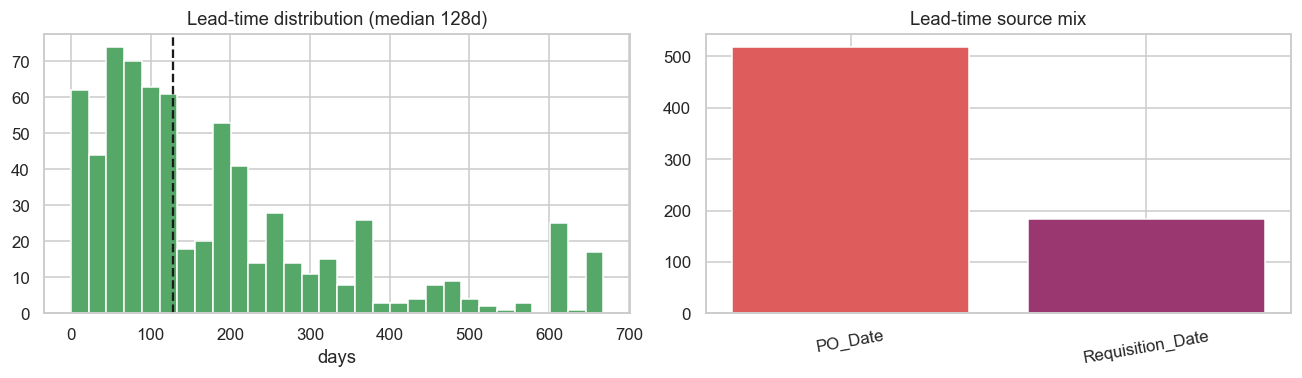

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
ltd=num(lt["Lead_Time_Days"])
axes[0].hist(ltd.clip(0,ltd.quantile(0.98)), bins=30, color="#55a868")
axes[0].axvline(ltd.median(),ls="--",c="k"); axes[0].set_title(f"Lead-time distribution (median {ltd.median():.0f}d)")
axes[0].set_xlabel("days")
sm=lt["Lead_Time_Source"].value_counts()
axes[1].bar(sm.index, sm.values, color=sns.color_palette("flare",len(sm)))
axes[1].set_title("Lead-time source mix"); axes[1].tick_params(axis="x",rotation=10)
plt.tight_layout(); plt.show()

## 7. Criticality Analytics (STEP23.8)
**How much inventory is operationally critical?** Reconstructed from the SUMMARY Type token
(Safety/Vital → Critical; NA → Non-Critical).

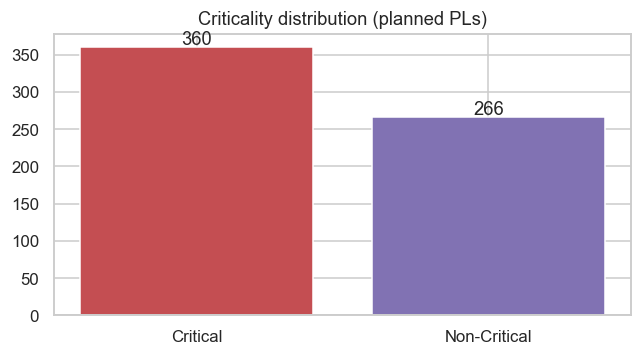

In [8]:
cc=rop["Criticality_Class"].value_counts()
fig,ax=plt.subplots(figsize=(6,3.4))
ax.bar(cc.index, cc.values, color=["#c44e52","#8172b3"])
ax.set_title("Criticality distribution (planned PLs)")
for i,v in enumerate(cc.values): ax.text(i,v+4,str(v),ha="center")
plt.tight_layout(); plt.show()

## 8. Safety Stock (STEP24)
**What drives inventory buffers?** SS = z·σ·√(LT/30.4375); higher service level for Critical items.

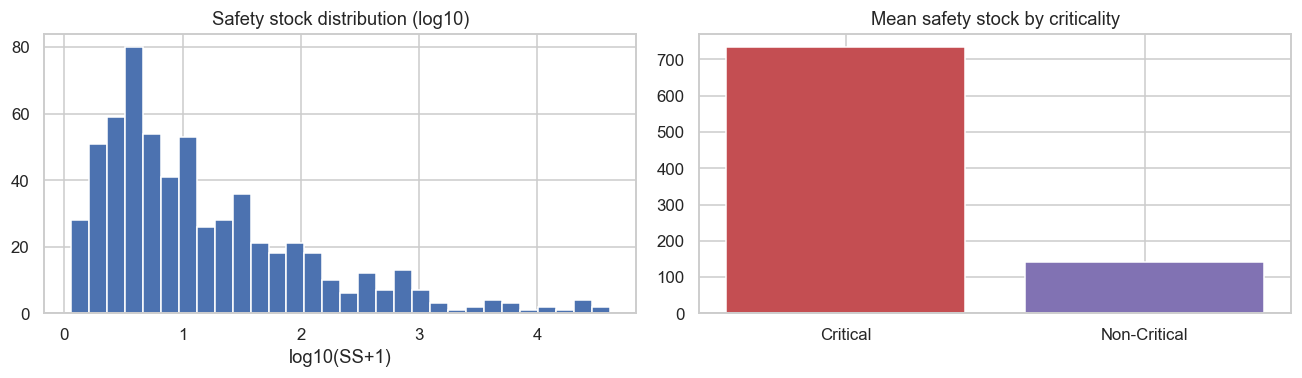

In [9]:
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
sval=ssr["Safety_Stock"]; sval=sval[sval>0]
axes[0].hist(np.log10(sval+1), bins=30, color="#4c72b0")
axes[0].set_title("Safety stock distribution (log10)"); axes[0].set_xlabel("log10(SS+1)")
mss=ssr.groupby("Criticality_Class")["Safety_Stock"].mean()
axes[1].bar(mss.index, mss.values, color=["#c44e52","#8172b3"])
axes[1].set_title("Mean safety stock by criticality")
plt.tight_layout(); plt.show()

## 9. Reorder Point (STEP25)
**What should be reordered?** ROP = DDLT + SS; stock status vs ROP. **465 of 626 in Critical Shortage.**

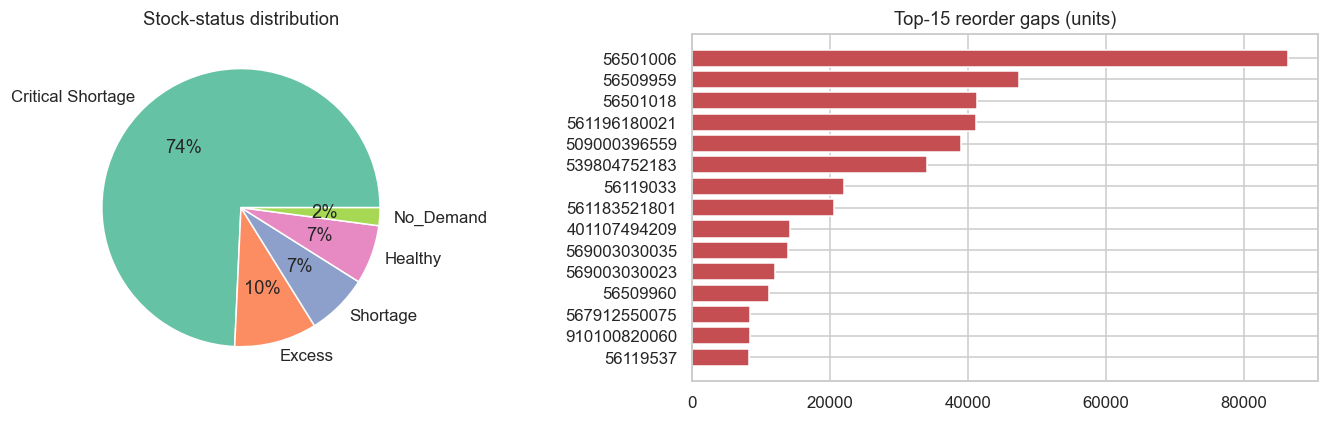

In [10]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
st=rop["Stock_Status"].value_counts()
axes[0].pie(st.values, labels=st.index, autopct="%1.0f%%", colors=sns.color_palette("Set2",len(st)))
axes[0].set_title("Stock-status distribution")
top=rop.nlargest(15,"Reorder_Gap")[["PL_Code","Reorder_Gap"]]
axes[1].barh(top["PL_Code"][::-1], top["Reorder_Gap"][::-1], color="#c44e52")
axes[1].set_title("Top-15 reorder gaps (units)")
plt.tight_layout(); plt.show()

## 10. SRRS Prioritization (STEP26)
**Where is service risk concentrated?** SRRS = Criticality_Weight × Service_Factor × Positive_Gap.
Top-10 carry **84.5%** of all risk — extreme concentration.

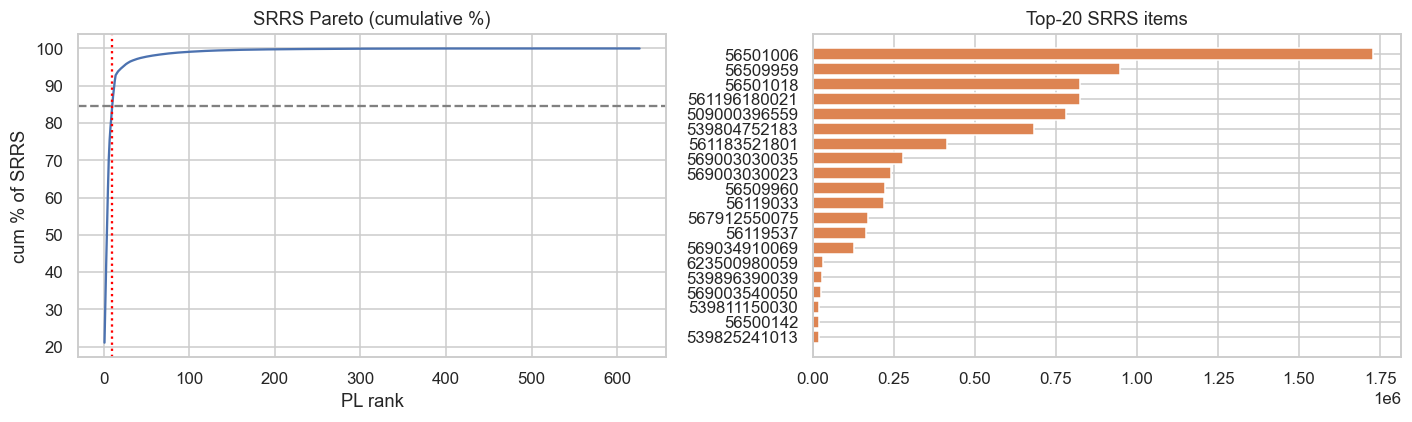

In [11]:
sr=srrs.sort_values("SRRS",ascending=False).reset_index(drop=True)
cum=sr["SRRS"].cumsum()/sr["SRRS"].sum()*100
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(range(1,len(cum)+1), cum.values, color="#4c72b0")
axes[0].axhline(84.5,ls="--",c="grey"); axes[0].axvline(10,ls=":",c="red")
axes[0].set_title("SRRS Pareto (cumulative %)"); axes[0].set_xlabel("PL rank"); axes[0].set_ylabel("cum % of SRRS")
t20=sr.head(20)
axes[1].barh(t20["PL_Code"][::-1], t20["SRRS"][::-1], color="#dd8452")
axes[1].set_title("Top-20 SRRS items")
plt.tight_layout(); plt.show()

## 11. Capital Exposure (STEP25.5)
**Where is procurement capital at risk?** Reorder-gap valued at unit cost. Current stock vs gap value.

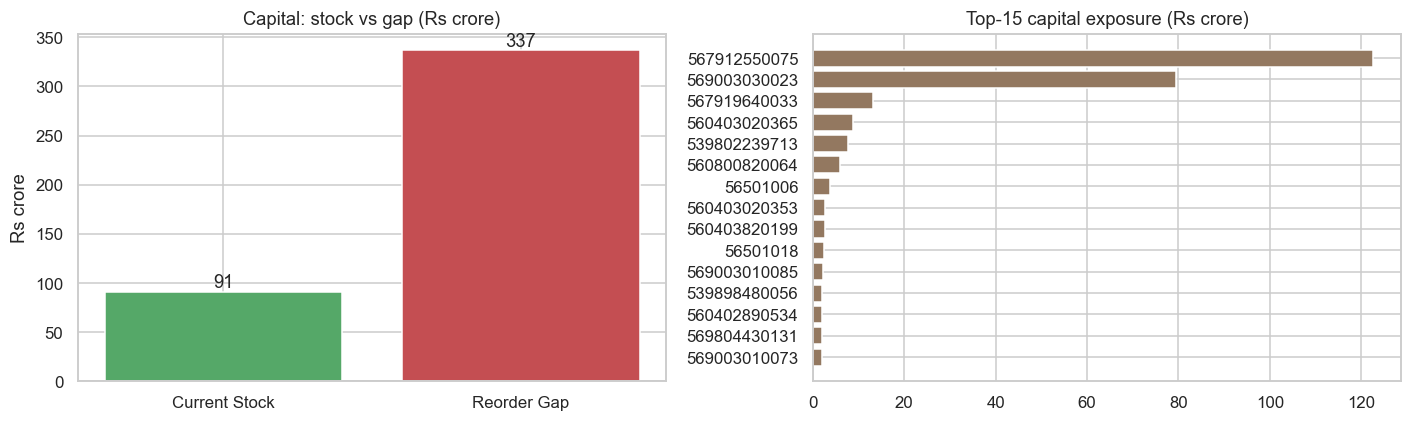

In [12]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
stock_v=(srrs["Current_Stock"]*srrs["Average_Rate_Rs"]).sum()/1e7
gap_v=srrs["Reorder_Gap_Value_Rs"].sum()/1e7
axes[0].bar(["Current Stock","Reorder Gap"], [stock_v,gap_v], color=["#55a868","#c44e52"])
axes[0].set_title("Capital: stock vs gap (Rs crore)"); axes[0].set_ylabel("Rs crore")
for i,v in enumerate([stock_v,gap_v]): axes[0].text(i,v,f"{v:,.0f}",ha="center",va="bottom")
tv=srrs.nlargest(15,"Reorder_Gap_Value_Rs")
axes[1].barh(tv["PL_Code"][::-1], (tv["Reorder_Gap_Value_Rs"]/1e7)[::-1], color="#937860")
axes[1].set_title("Top-15 capital exposure (Rs crore)")
plt.tight_layout(); plt.show()

## 12. Procurement Portfolio (STEP27)
**What should management procure first?** 5-tier risk×value segmentation. **Tier 1 = 6 PLs carrying 57.6% of SRRS.**

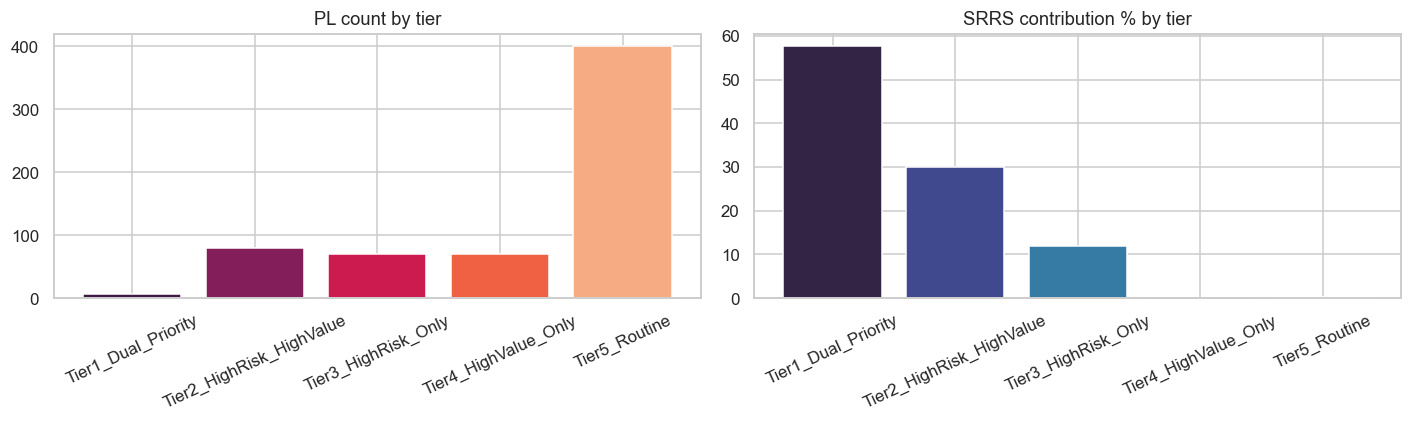

In [13]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].bar(pp["Tier"], pp["PL_Count"], color=sns.color_palette("rocket",len(pp)))
axes[0].set_title("PL count by tier"); axes[0].tick_params(axis="x",rotation=25)
axes[1].bar(pp["Tier"], num(pp["SRRS_Contribution_Pct"]), color=sns.color_palette("mako",len(pp)))
axes[1].set_title("SRRS contribution % by tier"); axes[1].tick_params(axis="x",rotation=25)
plt.tight_layout(); plt.show()

## 13. Business Case (STEP28)
**What was achieved?** A complete division planning capability built additively on the core platform,
fully validated and reproducibility-guarded.

In [14]:
print("ACHIEVED (evidence-backed):")
print(f"  - {len(dc)} PLs demand-classified; {len(fc)} forecast (88.7%); {len(lt)} lead-time (97.8%)")
print(f"  - {len(rop)} PLs planned (SS+ROP+SRRS); 465 critical shortages surfaced")
print(f"  - Rs {(srrs['Reorder_Gap_Value_Rs'].sum()/1e7):,.0f} crore reorder-gap exposure quantified")
print(f"  - Risk concentrated: top-10 = 84.5%; Tier-1 6 PLs = 57.6% of SRRS")
print(f"  - 541 tests green; reproducible-from-code baseline (Hardening A/B)")

ACHIEVED (evidence-backed):
  - 1083 PLs demand-classified; 961 forecast (88.7%); 702 lead-time (97.8%)
  - 626 PLs planned (SS+ROP+SRRS); 465 critical shortages surfaced
  - Rs 337 crore reorder-gap exposure quantified
  - Risk concentrated: top-10 = 84.5%; Tier-1 6 PLs = 57.6% of SRRS
  - 541 tests green; reproducible-from-code baseline (Hardening A/B)


## 14. Platform Hardening (Program A/B)
**Can the platform be maintained and extended?** Ingestion extracted (leak removed), config centralized,
regression baseline made reproducible.

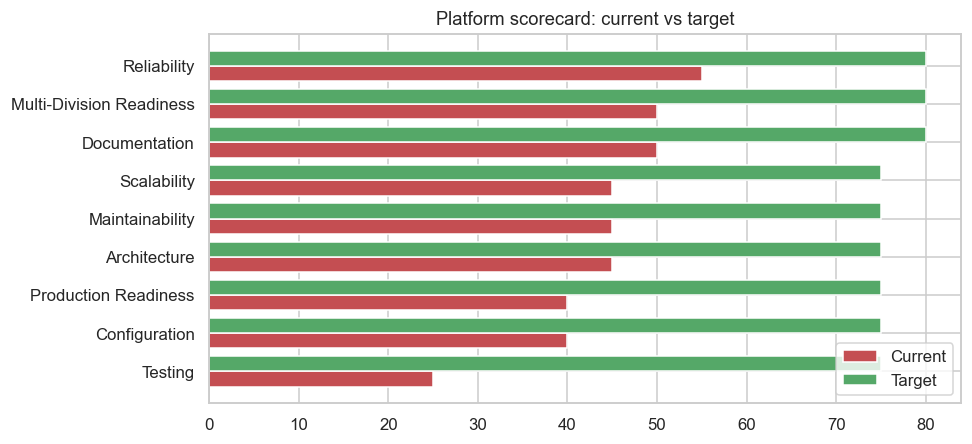

In [15]:
sc=score.sort_values("Current")
fig,ax=plt.subplots(figsize=(9,4.2))
y=np.arange(len(sc))
ax.barh(y-0.2, sc["Current"], height=0.4, label="Current", color="#c44e52")
ax.barh(y+0.2, sc["Target"], height=0.4, label="Target", color="#55a868")
ax.set_yticks(y); ax.set_yticklabels(sc["Dimension"]); ax.legend()
ax.set_title("Platform scorecard: current vs target")
plt.tight_layout(); plt.show()

## 15. Executive Dashboard
**L1 KPI cards + risk heatmap** — decision support for COS / DRM / Railway Board.

  L1 EXECUTIVE KPIs
  Forecast Coverage %         : 88.7
  Lead-Time Coverage %        : 97.8
  Criticality Coverage %      : 100.0
  Safety-Stock Coverage %     : 100.0
  ROP Coverage %              : 100.0
  SRRS Coverage %             : 100.0
  Current Stock Value (Rs)    : 913635687
  Reorder Gap Value (Rs)      : 3367367459
  Total SRRS                  : 8217896.6
  Top-10 Risk Concentration % : 84.5
  Tier 1 Count                : 6
  Tier 2 Count                : 80
  Platform Readiness          : 43.9 -> 76.7 (target)
  TPJ Readiness               : NO-GO (data-blocked); config-ready


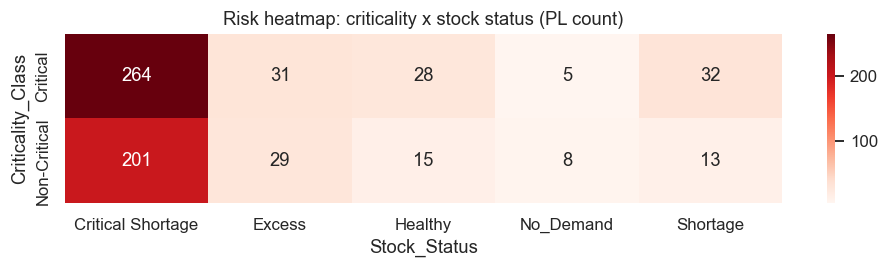

In [16]:
print("="*54); print("  L1 EXECUTIVE KPIs"); print("="*54)
for it in KPI["L1"]: print(f"  {it['KPI']:<28}: {it['Value']}")
ct=pd.crosstab(rop["Criticality_Class"], rop["Stock_Status"])
fig,ax=plt.subplots(figsize=(9,2.6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Reds", ax=ax)
ax.set_title("Risk heatmap: criticality x stock status (PL count)")
plt.tight_layout(); plt.show()

## 16. TPJ Readiness
**What blocks TPJ onboarding?** Config-ready; blocked only by TPJ data acquisition.

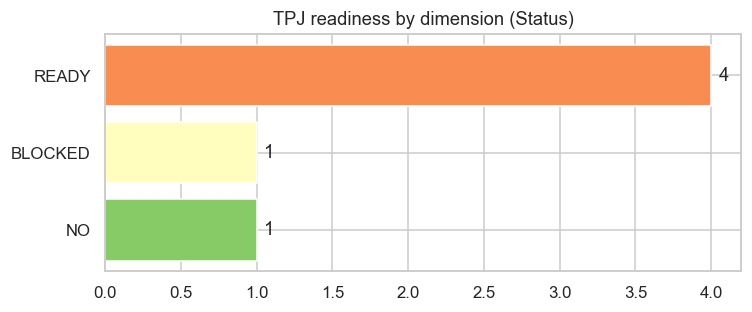

Verdict: NO-GO today (TPJ DMTR + SUMMARY data absent); config-ready otherwise.


In [17]:
rcol = next((c for c in ["Classification","Status"] if c in tpj.columns), tpj.columns[1])
rc = tpj[rcol].value_counts()
fig,ax=plt.subplots(figsize=(7,3))
ax.barh(rc.index[::-1], rc.values[::-1], color=sns.color_palette("RdYlGn_r", max(len(rc),3)))
ax.set_title("TPJ readiness by dimension ("+rcol+")")
for i,v in enumerate(rc.values[::-1]): ax.text(v+0.05,i,str(v),va="center")
plt.tight_layout(); plt.show()
print("Verdict: NO-GO today (TPJ DMTR + SUMMARY data absent); config-ready otherwise.")

## 17. Enterprise Capital Allocation & Budget Optimization (STEP35-OPT)

**How should Railway management allocate capital across divisions to maximise enterprise-wide service-risk reduction?** Built live from STEP35-OPT outputs: `risk_reduction_frontier.csv`, `budget_efficiency_analysis.csv`, `enterprise_budget_allocation.csv`, `procurement_roadmap.csv`, `executive_budget_scenarios.csv`, `enterprise_decision_dashboard.csv`.

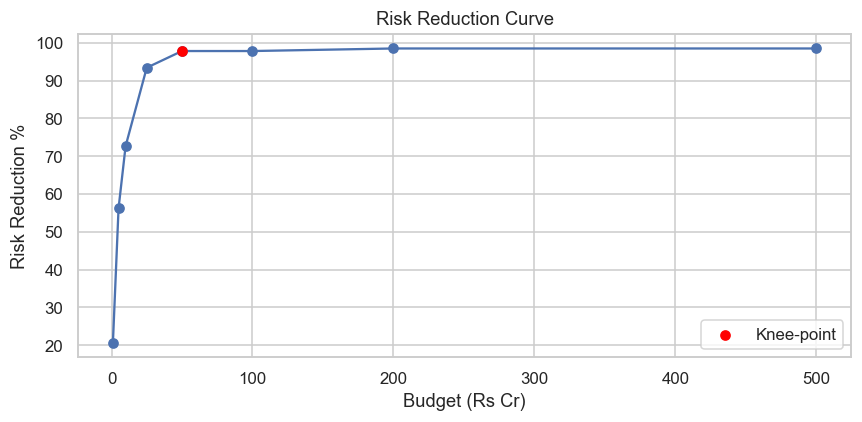

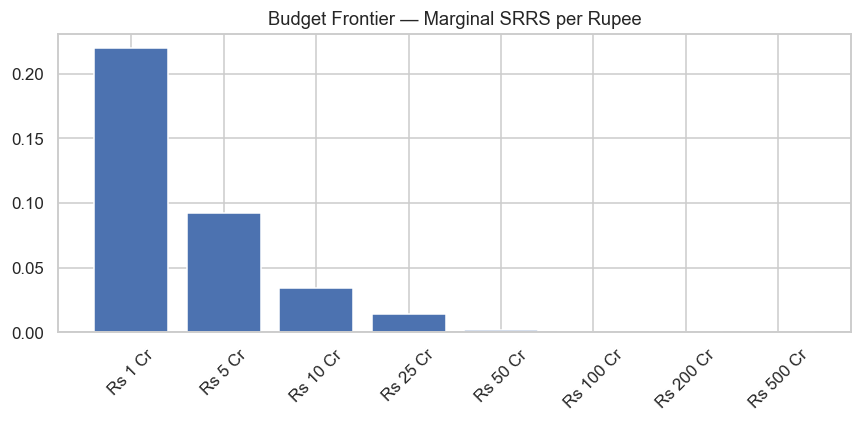

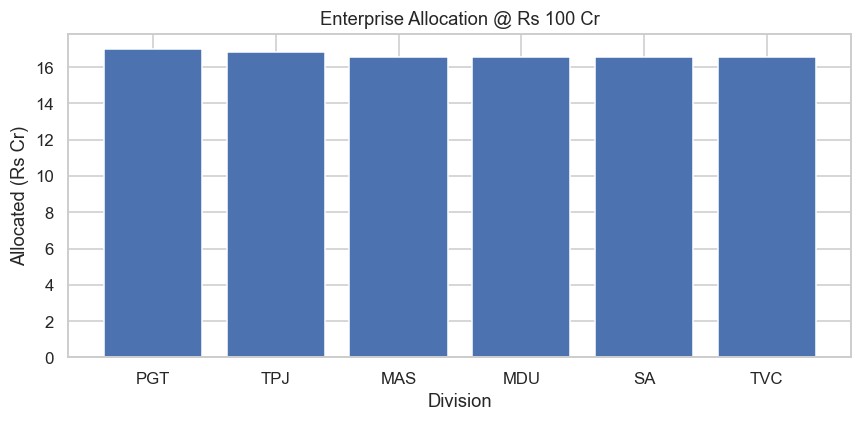

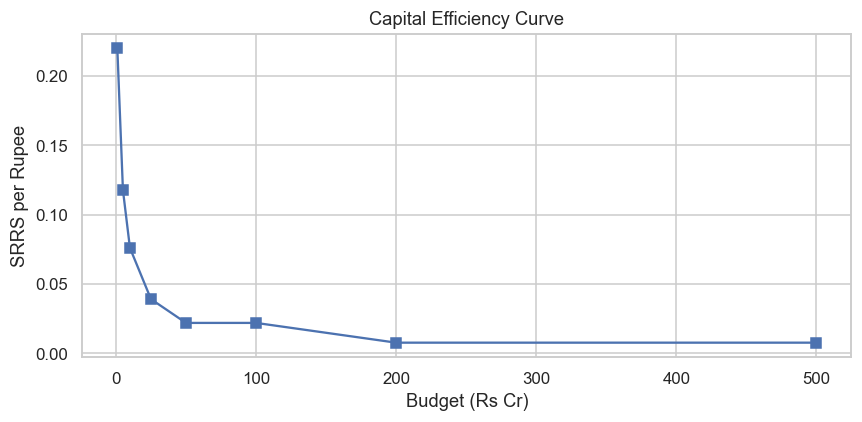

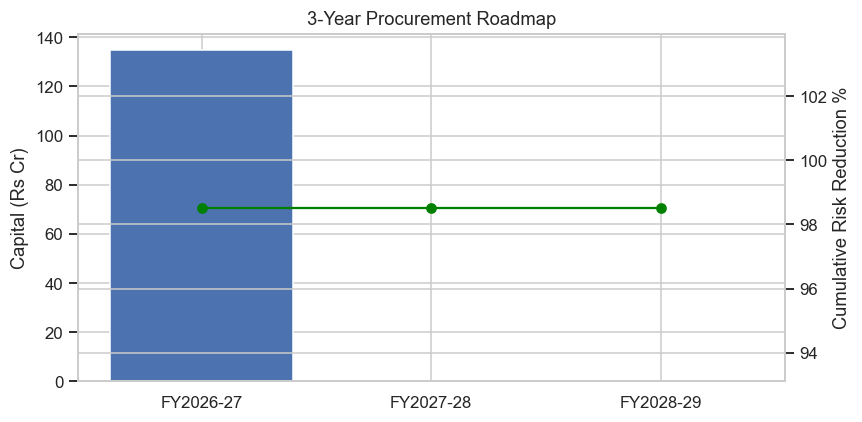

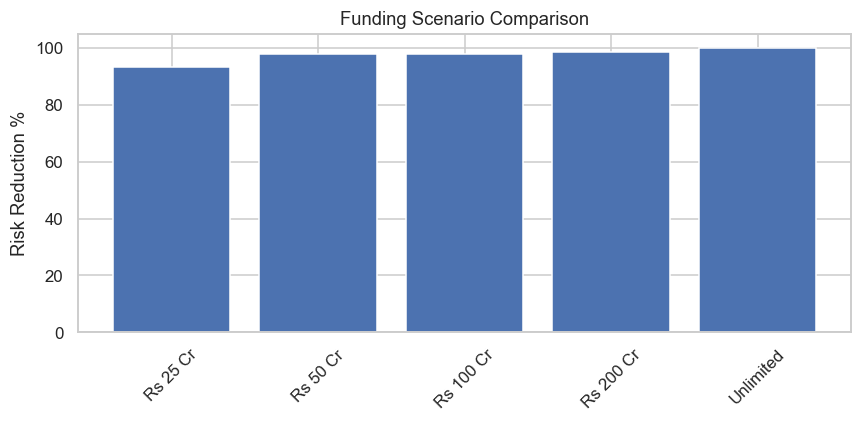

In [18]:
import pandas as pd, matplotlib.pyplot as plt
from railway import railway_config as cfg
O = cfg.OUTPUT_DIR
fr  = pd.read_csv(O/"risk_reduction_frontier.csv")
eff = pd.read_csv(O/"budget_efficiency_analysis.csv")
alc = pd.read_csv(O/"enterprise_budget_allocation.csv")
rm  = pd.read_csv(O/"procurement_roadmap.csv")
sc  = pd.read_csv(O/"executive_budget_scenarios.csv")
fin = fr[fr["Budget_Label"] != "Unlimited"]

# 1. Risk Reduction Curve
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(fin["Budget_Rupees"]/1e7, fin["Risk_Reduction_Pct"], marker="o")
knee = eff[eff["Is_Knee_Point"]]
if not knee.empty:
    kb = float(knee["Budget_Rupees"].iloc[0]); kr = float(fin.loc[fin["Budget_Label"]==knee["Budget_Label"].iloc[0], "Risk_Reduction_Pct"].iloc[0])
    ax.scatter([kb/1e7],[kr], color="red", zorder=5, label="Knee-point"); ax.legend()
ax.set_xlabel("Budget (Rs Cr)"); ax.set_ylabel("Risk Reduction %"); ax.set_title("Risk Reduction Curve")
plt.tight_layout(); plt.show()

# 2. Budget Frontier (marginal SRRS per rupee)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(fin["Budget_Label"], fin["Marginal_SRRS_Per_Rupee"])
ax.set_title("Budget Frontier — Marginal SRRS per Rupee"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 3. Enterprise Allocation Waterfall (at Rs 100 Cr)
h = alc[alc["Budget_Label"]=="Rs 100 Cr"].sort_values("Allocated_Budget", ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(h["Division"], h["Allocated_Budget"]/1e7)
ax.set_xlabel("Division"); ax.set_ylabel("Allocated (Rs Cr)")
ax.set_title("Enterprise Allocation @ Rs 100 Cr"); plt.tight_layout(); plt.show()

# 4. Capital Efficiency Curve
fig, ax = plt.subplots(figsize=(8,4))
ce = fin.assign(Eff=fin["SRRS_Mitigated"]/fin["Budget_Utilized"].replace(0, pd.NA))
ax.plot(ce["Budget_Rupees"]/1e7, ce["Eff"], marker="s")
ax.set_xlabel("Budget (Rs Cr)"); ax.set_ylabel("SRRS per Rupee"); ax.set_title("Capital Efficiency Curve")
plt.tight_layout(); plt.show()

# 5. Multi-Year Roadmap
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(rm["Year"], rm["Capital_Required"]/1e7, label="Capital (Rs Cr)")
ax2 = ax.twinx(); ax2.plot(rm["Year"], rm["Cumulative_Risk_Reduction_Pct"], color="green", marker="o", label="Cum. Risk Red. %")
ax.set_title("3-Year Procurement Roadmap"); ax.set_ylabel("Capital (Rs Cr)"); ax2.set_ylabel("Cumulative Risk Reduction %")
plt.tight_layout(); plt.show()

# 6. Funding Scenario Comparison
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(sc["Scenario"], sc["Risk_Reduction_Pct"])
ax.set_title("Funding Scenario Comparison"); ax.set_ylabel("Risk Reduction %"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()